In [1412]:
import pandas as pd
import geopandas as gpd
import os

# **Station Footfall Data filter**

In [1413]:
# Define the file path
input_path = '/content/drive/MyDrive/2026 Spring/Capstone/CAPSTONE WORK PROGRESS/Data/TfL Station Footfall/StationFootfall_2024_2025 .csv'

# Check if file exists before loading
if os.path.exists(input_path):
    # Load the CSV file
    df = pd.read_csv(input_path)

    display(df.head())
    print(df.info())
else:
    print(f"File not found at: {input_path}")

,TravelDate,DayOfWeek,Station,EntryTapCount,ExitTapCount
0,20240101,Monday,Abbey Road DLR,395,375
1,20240101,Monday,Abbey Wood,5898,5963
2,20240101,Monday,Acton Central,609,474
3,20240101,Monday,Acton Main Line,1717,1710
4,20240101,Monday,Acton Town,2928,3334


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 311447 entries, 0 to 311446
Data columns (total 5 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   TravelDate     311447 non-null  int64 
 1   DayOfWeek      311447 non-null  object
 2   Station        311447 non-null  object
 3   EntryTapCount  311447 non-null  int64 
 4   ExitTapCount   311447 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 11.9+ MB
None


In [1414]:
# Filter data for the period 20250301 to 20250430
start_date = 20250301
end_date = 20250430

# Filter the DataFrame
# TravelDate is int64, so integer comparison works correctly for YYYYMMDD format
footfall = df[(df['TravelDate'] >= start_date) & (df['TravelDate'] <= end_date)]

# Define output path
output_path = '/content/drive/MyDrive/2026 Spring/Capstone/CAPSTONE WORK PROGRESS/Data/TfL Station Footfall/StationFootfall_2025_03to04.csv'

# Export to CSV
footfall.to_csv(output_path, index=False)

print(f"Filtered data exported to: {output_path}")
print(f"Number of rows retained: {len(footfall)}")
display(footfall.head())

Filtered data exported to: /content/drive/MyDrive/2026 Spring/Capstone/CAPSTONE WORK PROGRESS/Data/TfL Station Footfall/StationFootfall_2025_03to04.csv
Number of rows retained: 26305


,TravelDate,DayOfWeek,Station,EntryTapCount,ExitTapCount
182399,20250301,Saturday,Abbey Road DLR,29,5
182400,20250301,Saturday,Abbey Wood,13221,12103
182401,20250301,Saturday,Acton Central,2095,2021
182402,20250301,Saturday,Acton Main Line,3543,3335
182403,20250301,Saturday,Acton Town,6105,6274


# **Merge TfL Stations**

Traverse the "TfL Stations" directory and its subfolders to find all `.shp` files. Load them into geopandas GeoDataFrames, concatenate them into a single GeoDataFrame (ensuring all unique columns are retained), and save the result as **geojson**.

## Find and Load Shapefiles


In [1415]:
# Define the root directory path
root_directory = '/content/drive/MyDrive/2026 Spring/Capstone/CAPSTONE WORK PROGRESS/Data/TfL Stations'

# Initialize a list to store GeoDataFrames
shapefile_gdfs = []

# Check if directory exists
if os.path.exists(root_directory):
    # Traverse the directory
    for root, dirs, files in os.walk(root_directory):
        for file in files:
            if file.endswith('.shp'):
                file_path = os.path.join(root, file)
                try:
                    # Load the shapefile
                    gdf = gpd.read_file(file_path)
                    shapefile_gdfs.append(gdf)
                    print(f"Loaded: {file_path}")
                except Exception as e:
                    print(f"Failed to load {file_path}: {e}")

    print(f"\nTotal shapefiles loaded: {len(shapefile_gdfs)}")
else:
    print(f"Directory not found: {root_directory}")

Loaded: /content/drive/MyDrive/2026 Spring/Capstone/CAPSTONE WORK PROGRESS/Data/TfL Stations/Tramlink_Stations/Tramlink_Stations.shp
Loaded: /content/drive/MyDrive/2026 Spring/Capstone/CAPSTONE WORK PROGRESS/Data/TfL Stations/Underground_Stations/Underground_Stations.shp
Loaded: /content/drive/MyDrive/2026 Spring/Capstone/CAPSTONE WORK PROGRESS/Data/TfL Stations/Elizabeth_Line_Stations/Elizabeth_Line_Stations.shp
Loaded: /content/drive/MyDrive/2026 Spring/Capstone/CAPSTONE WORK PROGRESS/Data/TfL Stations/Overground_Stations/Overground_Stations.shp
Loaded: /content/drive/MyDrive/2026 Spring/Capstone/CAPSTONE WORK PROGRESS/Data/TfL Stations/DLR_Stations/DLR_Stations.shp

Total shapefiles loaded: 5


## Merge and Export as geojson

In [1416]:
# Concatenate the list into a single GeoDataFrame
all_stations = pd.concat(shapefile_gdfs, ignore_index=True)

# Ensure all_stations is a GeoDataFrame (pd.concat might return a DataFrame)
if not isinstance(all_stations, gpd.GeoDataFrame):
    all_stations = gpd.GeoDataFrame(all_stations, geometry='geometry')

# Check and restore CRS if lost during concatenation
if all_stations.crs is None and len(shapefile_gdfs) > 0:
    all_stations.set_crs(shapefile_gdfs[0].crs, inplace=True)

# Sort by OBJECTID and reset index
all_stations = all_stations.sort_values(by='OBJECTID').reset_index(drop=True)

# Define output path
output_path = "/content/drive/MyDrive/2026 Spring/Capstone/CAPSTONE WORK PROGRESS/Data/TfL Stations/TfL_All_Stations.geojson"

# Save to GeoJSON
all_stations.to_file(output_path, driver='GeoJSON')

# Print summary statistics
print(f"Number of source files merged: {len(shapefile_gdfs)}")
print(f"Total number of stations: {len(all_stations)}")

# Display first few rows and info
display(all_stations.head(2))
print(all_stations.info())

Number of source files merged: 5
Total number of stations: 510


,OBJECTID,NAME,ACCESSIBIL,NETWORK,DATASET_LA,FULL_NAME,geometry,LINES,ATCOCODE,MODES,NIGHT_TUBE
0,1,London Fields,Not Accessible,London Overground,2023-05-23,London Fields station,POINT Z (534775 184246 0),NaN,NaN,NaN,NaN
1,2,Canonbury,Fully Accessible,London Overground,2023-05-23,Canonbury station,POINT Z (532354.998 185024.996 0),NaN,NaN,NaN,NaN


<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 510 entries, 0 to 509
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   OBJECTID    510 non-null    int32         
 1   NAME        510 non-null    object        
 2   ACCESSIBIL  508 non-null    object        
 3   NETWORK     510 non-null    object        
 4   DATASET_LA  510 non-null    datetime64[ms]
 5   FULL_NAME   510 non-null    object        
 6   geometry    510 non-null    geometry      
 7   LINES       314 non-null    object        
 8   ATCOCODE    271 non-null    object        
 9   MODES       273 non-null    object        
 10  NIGHT_TUBE  273 non-null    object        
dtypes: datetime64[ms](1), geometry(1), int32(1), object(8)
memory usage: 42.0+ KB
None


In [1417]:
# Check if OBJECTID unique
is_unique = all_stations['OBJECTID'].is_unique
print(f"Is OBJECTID unique? {is_unique}")

Is OBJECTID unique? True


In [1418]:
# Create an interactive map of the stations
# Use explore to visualize the stations interactively
station_map = all_stations.explore(
    column='NETWORK',       # Color markers by Network
    tooltip=['NAME', 'NETWORK', 'LINES'], # Show info on hover
    popup=True,             # Show all info on click
    cmap='tab10',           # Color palette
    tiles='CartoDB positron', # Clean background map
    legend=True
)
display(station_map)

# **TfL Stations without trams**
Because footfall data didn't include Tramlink

In [1419]:
# Filter out Tramlink stations
tube_rail_stations = all_stations[all_stations['NETWORK'] != 'Tramlink'].copy()

# Reset index
tube_rail_stations = tube_rail_stations.reset_index(drop=True)

# Define output path
output_path = "/content/drive/MyDrive/2026 Spring/Capstone/CAPSTONE WORK PROGRESS/Data/TfL Stations/TfL_Tube_Rail_Stations.geojson"

# Save to GeoJSON
tube_rail_stations.to_file(output_path, driver='GeoJSON')

print(f"Original stations count: {len(all_stations)}")
print(f"Stations without Tramlink: {len(tube_rail_stations)}")
print("\nRemaining Networks:")
print(tube_rail_stations['NETWORK'].unique())

display(tube_rail_stations.head())

Original stations count: 510
Stations without Tramlink: 471

Remaining Networks:
['London Overground' 'London Underground' 'DLR' 'TfL Rail']


,OBJECTID,NAME,ACCESSIBIL,NETWORK,DATASET_LA,FULL_NAME,geometry,LINES,ATCOCODE,MODES,NIGHT_TUBE
0,1,London Fields,Not Accessible,London Overground,2023-05-23,London Fields station,POINT Z (534775 184246 0),NaN,NaN,NaN,NaN
1,2,Canonbury,Fully Accessible,London Overground,2023-05-23,Canonbury station,POINT Z (532354.998 185024.996 0),NaN,NaN,NaN,NaN
2,3,Dalston Junction,Fully Accessible,London Overground,2023-05-23,Dalston Junction station,POINT Z (533575.3 184768.013 0),NaN,NaN,NaN,NaN
3,4,Edmondton Green,Not Accessible,London Overground,2023-05-23,Edmondton Green station,POINT Z (534297.108 193554.092 0),NaN,NaN,NaN,NaN
4,5,Haggerston,Fully Accessible,London Overground,2023-05-23,Haggerston station,POINT Z (533560.442 183964.732 0),NaN,NaN,NaN,NaN


# **Match stations**

## **Prepare**

Get new df for station matching

In [1420]:
tube_rail_station_names = tube_rail_stations[['OBJECTID', 'NAME', 'NETWORK', 'LINES']].copy()

# If 'LINES' is 'Elizabeth Line', change 'NETWORK' to 'Elizabeth Line'
tube_rail_station_names.loc[tube_rail_station_names['LINES'] == 'Elizabeth Line', 'NETWORK'] = 'Elizabeth Line'

# If 'NETWORK' is 'DLR', remove ' - DLR' from 'NAME', and change the rest from all cap to only cap the first letter
tube_rail_station_names.loc[tube_rail_station_names['NETWORK'] == 'DLR', 'NAME'] = tube_rail_station_names[tube_rail_station_names['NETWORK'] == 'DLR']['NAME'].str.replace(' - DLR', '').str.title()

# Sort by NAME
tube_rail_station_names = tube_rail_station_names.sort_values(by='NAME')

display(tube_rail_station_names)
print(tube_rail_station_names.info())

,OBJECTID,NAME,NETWORK,LINES
341,345,Abbey Road,DLR,NaN
392,406,Abbey Wood,Elizabeth Line,Elizabeth Line
82,83,Acton Central,London Overground,NaN
413,427,Acton Main Line,Elizabeth Line,Elizabeth Line
290,291,Acton Town,London Underground,"District, Piccadilly"
...,...,...,...,...
121,122,Woodford,London Underground,Central
18,19,Woodgrange Park,London Overground,NaN
452,486,Woodside Park,London Underground,Northern
393,407,Woolwich,Elizabeth Line,Elizabeth Line


<class 'pandas.core.frame.DataFrame'>
Index: 471 entries, 341 to 458
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   OBJECTID  471 non-null    int32 
 1   NAME      471 non-null    object
 2   NETWORK   471 non-null    object
 3   LINES     314 non-null    object
dtypes: int32(1), object(3)
memory usage: 16.6+ KB
None


In [1421]:
tube_rail_station_names.loc[tube_rail_station_names['NETWORK'] == 'DLR'].head(2)

,OBJECTID,NAME,NETWORK,LINES
341,345,Abbey Road,DLR,NaN
346,360,All Saints,DLR,NaN


Check if NAME column in station_names is unique

In [1422]:
# Check if NAME column is unique
is_unique = tube_rail_station_names['NAME'].is_unique
print(f"Are all station names unique? {is_unique}")

if not is_unique:
    # Find and display duplicates
    duplicates = tube_rail_station_names[tube_rail_station_names.duplicated(subset=['NAME'], keep=False)]
    print(f"\nFound {len(duplicates)} records with duplicate names:")
    display(duplicates.sort_values(by='NAME'))

Are all station names unique? False

Found 88 records with duplicate names:


,OBJECTID,NAME,NETWORK,LINES
208,209,Bank,London Underground,"Waterloo & City, Northern, Central"
338,342,Bank,DLR,NaN
386,400,Barking,London Underground,"District, Hammersmith & City"
20,21,Barking,London Overground,NaN
112,113,Bethnal Green,London Underground,Central
...,...,...,...,...
395,409,Whitechapel,Elizabeth Line,Elizabeth Line
17,18,Whitechapel,London Overground,NaN
309,310,Whitechapel,London Underground,"District, Hammersmith & City"
65,66,Willesden Junction,London Overground,NaN


In [1423]:
# Get a list with NAME contains ''' or '.'
names_with_special_chars = tube_rail_station_names[tube_rail_station_names['NAME'].str.contains(r'''['.]''')]
names_with_special_chars

,OBJECTID,NAME,NETWORK,LINES
198,199,Earl's Court,London Underground,"District, Piccadilly"
166,167,King's Cross St. Pancras,London Underground,"Metropolitan, Northern, Piccadilly, Circle, Vi..."
199,200,Queen's Park,London Underground,Bakerloo
275,276,Regent's Park,London Underground,Bakerloo
181,182,Shepherd's Bush,London Underground,Central
193,194,Shepherd's Bush Market,London Underground,"Hammersmith & City, Circle"
12,13,St. James Street,London Overground,NaN
384,398,St. James's Park,London Underground,"District, Circle"
331,332,St. John's Wood,London Underground,Jubilee
110,111,St. Paul's,London Underground,Central


In [1424]:
# Remove ''' and '.' from NAME
tube_rail_station_names['NAME'] = tube_rail_station_names['NAME'].str.replace(r'''['.]''', '', regex=True)
tube_rail_station_names

,OBJECTID,NAME,NETWORK,LINES
341,345,Abbey Road,DLR,NaN
392,406,Abbey Wood,Elizabeth Line,Elizabeth Line
82,83,Acton Central,London Overground,NaN
413,427,Acton Main Line,Elizabeth Line,Elizabeth Line
290,291,Acton Town,London Underground,"District, Piccadilly"
...,...,...,...,...
121,122,Woodford,London Underground,Central
18,19,Woodgrange Park,London Overground,NaN
452,486,Woodside Park,London Underground,Northern
393,407,Woolwich,Elizabeth Line,Elizabeth Line


Unique footfall stations

In [1425]:
# Get unique stations and sort them
unique_stations_footfall = footfall['Station'].unique()
unique_stations_footfall.sort()

print(f"Number of unique stations in footfall data: {len(unique_stations_footfall)}")
print("Unique Stations:")
print(unique_stations_footfall)

Number of unique stations in footfall data: 434
Unique Stations:
['Abbey Road DLR' 'Abbey Wood' 'Acton Central' 'Acton Main Line'
 'Acton Town' 'Aldgate' 'Aldgate East' 'All Saints' 'Alperton' 'Amersham'
 'Anerley' 'Angel' 'Archway' 'Arnos Grove' 'Arsenal' 'Baker Street'
 'Balham' 'Bank' 'Barbican' 'Barking' 'Barking Riverside' 'Barkingside'
 'Barons Court' 'Battersea Power Station' 'Bayswater' 'Beckton'
 'Beckton Park' 'Becontree' 'Belsize Park' 'Bermondsey' 'Bethnal Green'
 'Bethnal Green NR' 'Blackfriars' 'Blackhorse Road' 'Blackwall'
 'Bond Street' 'Borough' 'Boston Manor' 'Bounds Green' 'Bow Church'
 'Bow Road' 'Brent Cross' 'Brentwood' 'Brixton' 'Brockley'
 'Bromley-by-Bow' 'Brondesbury' 'Brondesbury Park' 'Bruce Grove'
 'Buckhurst Hill' 'Burnham Bucks' 'Burnt Oak' 'Bush Hill Park' 'Bushey'
 'Caledonian Road' 'Caledonian Road & Barnsbury' 'Cambridge Heath'
 'Camden Road' 'Camden Town' 'Canada Water' 'Canary Wharf'
 'Canary Wharf DLR' 'Canary Wharf EL' 'Canning Town' 'Cannon Stree

## **Match names**

Match all station names in unique_stations_footfall with stations in tube_rail_station_names based on 'NAME' and 'NETWORK'.

Rules: in unique_stations_footfall, if there are stations with the same station names but from different 'NETWORK', a suffix is added: "EL" = "Elizabeth Line"; "LO" = "London Overground"; "DLR" = "DLR"; "NR" = "London Overground"

(Notes from Data Guide: Taps data for National Rail only stations have been excluded. Bethnal Green NR, Euston NR and Liverpool St NR are all part of the Overground network as well.)

In [1426]:
# Create a new DataFrame with unique footfall stations
footfall_station_match = pd.DataFrame({'footfall_station': unique_stations_footfall})

# Initialize columns
footfall_station_match['matched'] = False
footfall_station_match[['OBJECTID', 'NAME', 'NETWORK', 'LINES']] = None

# Set OBJECTID as int32
footfall_station_match['OBJECTID'] = footfall_station_match['OBJECTID'].astype('Int32')

display(footfall_station_match.head())
print(footfall_station_match.dtypes)

,footfall_station,matched,OBJECTID,NAME,NETWORK,LINES
0,Abbey Road DLR,False,<NA>,None,None,None
1,Abbey Wood,False,<NA>,None,None,None
2,Acton Central,False,<NA>,None,None,None
3,Acton Main Line,False,<NA>,None,None,None
4,Acton Town,False,<NA>,None,None,None


footfall_station    object
matched               bool
OBJECTID             Int32
NAME                object
NETWORK             object
LINES               object
dtype: object


In [1427]:
# Copy tube_rail_station_names to monitor unmatched station names
tube_rail_station_names_unmatched = tube_rail_station_names.copy()

**Round 1 - Exact Match**

In [1428]:
# Identify stations in the spatial dataset that have unique names
# (i.e., names that appear only once in tube_rail_station_names_unmatched)
name_counts = tube_rail_station_names_unmatched['NAME'].value_counts()
unique_names_in_gdf = name_counts[name_counts == 1].index

# Filter the reference DataFrame to only these unique stations and create a lookup
unique_lookup = tube_rail_station_names_unmatched[tube_rail_station_names_unmatched['NAME'].isin(unique_names_in_gdf)].set_index('NAME')

# Function to apply matching
def match_exact_unique(row):
    # Only process if not already matched
    if not row['matched']:
        # Check if the footfall station name exists as a unique name in the spatial data
        if row['footfall_station'] in unique_lookup.index:
            match_data = unique_lookup.loc[row['footfall_station']]
            return pd.Series([True, match_data['OBJECTID'], match_data.name, match_data['NETWORK'], match_data['LINES']])

    # Return original values if no match found
    return pd.Series([row['matched'], row['OBJECTID'], row['NAME'], row['NETWORK'], row['LINES']])

# Apply the matching logic
footfall_station_match[['matched', 'OBJECTID', 'NAME', 'NETWORK', 'LINES']] = footfall_station_match.apply(match_exact_unique, axis=1)

# Remove matched stations from tube_rail_station_names_unmatched
matched_ids = footfall_station_match.loc[footfall_station_match['matched'], 'OBJECTID'].dropna()
tube_rail_station_names_unmatched = tube_rail_station_names_unmatched[~tube_rail_station_names_unmatched['OBJECTID'].isin(matched_ids)]

print(f"Matches found in Round 1: {footfall_station_match['matched'].sum()}")
print(f"Matches not found in Round 1: {len(footfall_station_match) - footfall_station_match['matched'].sum()}")
print(f"Remaining unmatched stations in pool: {len(tube_rail_station_names_unmatched)}")
display(footfall_station_match.head())

Matches found in Round 1: 358
Matches not found in Round 1: 76
Remaining unmatched stations in pool: 113


,footfall_station,matched,OBJECTID,NAME,NETWORK,LINES
0,Abbey Road DLR,False,<NA>,None,None,None
1,Abbey Wood,True,406,Abbey Wood,Elizabeth Line,Elizabeth Line
2,Acton Central,True,83,Acton Central,London Overground,NaN
3,Acton Main Line,True,427,Acton Main Line,Elizabeth Line,Elizabeth Line
4,Acton Town,True,291,Acton Town,London Underground,"District, Piccadilly"


In [1429]:
footfall_station_match[~footfall_station_match['matched']]

,footfall_station,matched,OBJECTID,NAME,NETWORK,LINES
0,Abbey Road DLR,False,<NA>,None,None,None
17,Bank,False,<NA>,None,None,None
19,Barking,False,<NA>,None,None,None
30,Bethnal Green,False,<NA>,None,None,None
31,Bethnal Green NR,False,<NA>,None,None,None
...,...,...,...,...,...,...
420,Whitechapel,False,<NA>,None,None,None
422,Willesden Junction,False,<NA>,None,None,None
431,Woolwich Arsenal DLR,False,<NA>,None,None,None
432,Woolwich Arsenal NR,False,<NA>,None,None,None


**Round 2 - Match with suffix**

For stations in `footfall_station_match` that are still unmatched:
1.  Check if the station name ends with one of the following suffixes: `' DLR'`, `' EL'`, `' NR'`, or `' LO'`.
2.  Map these suffixes to their corresponding networks:
    *   `' DLR'` -> `'DLR'`
    *   `' EL'` -> `'Elizabeth Line'`
    *   `' NR'` -> `'London Overground'`
    *   `' LO'` -> `'London Overground'`
3.  Strip the suffix to get the base station name.
4.  Find a match in `tube_rail_station_names` where both the `NAME` matches the base name and the `NETWORK` matches the mapped network.
5.  Update `footfall_station_match` with the found `OBJECTID`, `NAME`, `NETWORK`, and `LINES`.
6.  Display the number of new matches found and the count of remaining unmatched stations.

In [1430]:
# Define suffix map
suffix_map = {' DLR': 'DLR', ' EL': 'Elizabeth Line', ' NR': 'London Overground', ' LO': 'London Overground'}

# Count matches before this round
matches_before = footfall_station_match['matched'].sum()

# Function to apply matching with suffix
def match_suffix(row):
    # Skip if already matched
    if row['matched']:
        return pd.Series([row['matched'], row['OBJECTID'], row['NAME'], row['NETWORK'], row['LINES']])

    station_name = row['footfall_station']

    for suffix, network in suffix_map.items():
        if station_name.endswith(suffix):
            base_name = station_name[:-len(suffix)] # Strip suffix

            # Filter reference data for exact name and network match
            # We use the full tube_rail_station_names to ensure we find the correct network match
            match = tube_rail_station_names[
                (tube_rail_station_names['NAME'] == base_name) &
                (tube_rail_station_names['NETWORK'] == network)
            ]

            if not match.empty:
                # Check the size of match
                if len(match) > 1:
                    print(f"Multiple matches found for {base_name} with network {network}:")
                    display(match)
                # Use the first match found
                m = match.iloc[0]
                return pd.Series([True, m['OBJECTID'], m['NAME'], m['NETWORK'], m['LINES']])

    # No match found
    return pd.Series([False, row['OBJECTID'], row['NAME'], row['NETWORK'], row['LINES']])

# Apply the matching logic
footfall_station_match[['matched', 'OBJECTID', 'NAME', 'NETWORK', 'LINES']] = footfall_station_match.apply(match_suffix, axis=1)

# Remove matched stations from tube_rail_station_names_unmatched
matched_ids = footfall_station_match.loc[footfall_station_match['matched'], 'OBJECTID'].dropna()
tube_rail_station_names_unmatched = tube_rail_station_names_unmatched[~tube_rail_station_names_unmatched['OBJECTID'].isin(matched_ids)]

# Calculate statistics
matches_after = footfall_station_match['matched'].sum()
matches_found = matches_after - matches_before
remaining_unmatched = len(footfall_station_match) - matches_after

print(f"Matches found in Round 2: {matches_found}")
print(f"Total matches so far: {matches_after}")
print(f"Remaining unmatched footfall stations: {remaining_unmatched}")
print(f"Remaining unmatched stations in pool: {len(tube_rail_station_names_unmatched)}")

# Display updated dataframe and rows that were matched in this round (for verification)
newly_matched = footfall_station_match[(footfall_station_match['matched']) &
                                       (footfall_station_match['footfall_station'].str.endswith(tuple(suffix_map.keys())))]
display(footfall_station_match.head())
display(newly_matched)

Matches found in Round 2: 18
Total matches so far: 376
Remaining unmatched footfall stations: 58
Remaining unmatched stations in pool: 95


,footfall_station,matched,OBJECTID,NAME,NETWORK,LINES
0,Abbey Road DLR,True,345,Abbey Road,DLR,NaN
1,Abbey Wood,True,406,Abbey Wood,Elizabeth Line,Elizabeth Line
2,Acton Central,True,83,Acton Central,London Overground,NaN
3,Acton Main Line,True,427,Acton Main Line,Elizabeth Line,Elizabeth Line
4,Acton Town,True,291,Acton Town,London Underground,"District, Piccadilly"


,footfall_station,matched,OBJECTID,NAME,NETWORK,LINES
0,Abbey Road DLR,True,345,Abbey Road,DLR,NaN
31,Bethnal Green NR,True,39,Bethnal Green,London Overground,NaN
61,Canary Wharf DLR,True,363,Canary Wharf,DLR,NaN
62,Canary Wharf EL,True,505,Canary Wharf,Elizabeth Line,Elizabeth Line
93,Custom House DLR,True,464,Custom House,DLR,NaN
94,Custom House EL,True,404,Custom House,Elizabeth Line,Elizabeth Line
127,Euston NR,True,79,Euston,London Overground,NaN
225,Lewisham DLR,True,501,Lewisham,DLR,NaN
230,Limehouse DLR,True,373,Limehouse,DLR,NaN
276,Paddington EL,True,411,Paddington,Elizabeth Line,Elizabeth Line


**Round 3 - Try exact match again with the remaining stations**

In [1431]:
# Count matches before this round
matches_before = footfall_station_match['matched'].sum()

# Identify stations in the spatial dataset that have unique names
# (i.e., names that appear only once in tube_rail_station_names_unmatched)
name_counts = tube_rail_station_names_unmatched['NAME'].value_counts()
unique_names_in_gdf = name_counts[name_counts == 1].index

# Filter the reference DataFrame to only these unique stations and create a lookup
unique_lookup = tube_rail_station_names_unmatched[tube_rail_station_names_unmatched['NAME'].isin(unique_names_in_gdf)].set_index('NAME')

# Function to apply matching
def match_exact_unique_2(row):
    # Skip if already matched
    if row['matched']:
        return pd.Series([row['matched'], row['OBJECTID'], row['NAME'], row['NETWORK'], row['LINES']])

    # Check if the footfall station name exists as a unique name in the spatial data
    if row['footfall_station'] in unique_lookup.index:
        match_data = unique_lookup.loc[row['footfall_station']]
        return pd.Series([True, match_data['OBJECTID'], match_data.name, match_data['NETWORK'], match_data['LINES']])

    # Return original values if no match found
    return pd.Series([row['matched'], row['OBJECTID'], row['NAME'], row['NETWORK'], row['LINES']])

# Apply the matching logic
footfall_station_match[['matched', 'OBJECTID', 'NAME', 'NETWORK', 'LINES']] = footfall_station_match.apply(match_exact_unique_2, axis=1)

# Remove matched stations from tube_rail_station_names_unmatched
matched_ids = footfall_station_match.loc[footfall_station_match['matched'], 'OBJECTID'].dropna()
tube_rail_station_names_unmatched = tube_rail_station_names_unmatched[~tube_rail_station_names_unmatched['OBJECTID'].isin(matched_ids)]

# Calculate statistics
matches_after = footfall_station_match['matched'].sum()
matches_found = matches_after - matches_before
remaining_unmatched = len(footfall_station_match) - matches_after

print(f"Matches found in Round 3: {matches_found}")
print(f"Total matches so far: {matches_after}")
print(f"Remaining unmatched footfall stations: {remaining_unmatched}")
print(f"Remaining unmatched stations in pool: {len(tube_rail_station_names_unmatched)}")

display(footfall_station_match.head())

Matches found in Round 3: 5
Total matches so far: 381
Remaining unmatched footfall stations: 53
Remaining unmatched stations in pool: 90


,footfall_station,matched,OBJECTID,NAME,NETWORK,LINES
0,Abbey Road DLR,True,345,Abbey Road,DLR,NaN
1,Abbey Wood,True,406,Abbey Wood,Elizabeth Line,Elizabeth Line
2,Acton Central,True,83,Acton Central,London Overground,NaN
3,Acton Main Line,True,427,Acton Main Line,Elizabeth Line,Elizabeth Line
4,Acton Town,True,291,Acton Town,London Underground,"District, Piccadilly"


**Round 4 - Prioritize 'London Underground'**

For each unmatched footfall_station in footfall_station_match, try to match it with the entry in tube_rail_station_names_unmatched that shares the same name and NETWORK is 'London Underground', and drop all entries from tube_rail_station_names_unmatched that share this name.

In [1432]:
# Count matches before this round
matches_before = footfall_station_match['matched'].sum()

# Filter the unmatched pool for London Underground stations
lu_pool = tube_rail_station_names_unmatched[tube_rail_station_names_unmatched['NETWORK'] == 'London Underground']

# Find unmatched footfall stations that have a name match in the LU pool
unmatched_mask = ~footfall_station_match['matched']
matchable_names = set(footfall_station_match.loc[unmatched_mask, 'footfall_station']).intersection(set(lu_pool['NAME']))

print(f"Identified {len(matchable_names)} stations to match in this round.")

# Check for duplicates in LU pool before creating lookup
duplicates_in_pool = lu_pool[lu_pool.duplicated(subset=['NAME'], keep=False)]
if not duplicates_in_pool.empty:
    print(f"\nFound {len(duplicates_in_pool)} duplicate entries in LU pool (will take the first one):")
    display(duplicates_in_pool.sort_values(by='NAME'))

# Create a lookup from the LU pool for efficient data retrieval
# If there are duplicates in LU pool for the same name, take the first one
lu_lookup = lu_pool.drop_duplicates(subset='NAME').set_index('NAME')

# Function to apply match
def match_round4(row):
    if not row['matched'] and row['footfall_station'] in matchable_names:
        match_data = lu_lookup.loc[row['footfall_station']]
        return pd.Series([True, match_data['OBJECTID'], match_data.name, match_data['NETWORK'], match_data['LINES']])
    return pd.Series([row['matched'], row['OBJECTID'], row['NAME'], row['NETWORK'], row['LINES']])

# Apply the update
footfall_station_match[['matched', 'OBJECTID', 'NAME', 'NETWORK', 'LINES']] = footfall_station_match.apply(match_round4, axis=1)

# Drop all entries from the unmatched pool that share these names (regardless of network)
if matchable_names:
    tube_rail_station_names_unmatched = tube_rail_station_names_unmatched[~tube_rail_station_names_unmatched['NAME'].isin(matchable_names)]

# Calculate statistics
matches_after = footfall_station_match['matched'].sum()
matches_found = matches_after - matches_before
remaining_unmatched = len(footfall_station_match) - matches_after

print(f"Matches found in Round 4: {matches_found}")
print(f"Total matches so far: {matches_after}")
print(f"Remaining unmatched footfall stations: {remaining_unmatched}")
print(f"Remaining unmatched stations in pool: {len(tube_rail_station_names_unmatched)}")

# Display newly matched rows
if matches_found > 0:
    display(footfall_station_match[footfall_station_match['footfall_station'].isin(matchable_names)].head())

Identified 34 stations to match in this round.

Found 2 duplicate entries in LU pool (will take the first one):


,OBJECTID,NAME,NETWORK,LINES
124,125,Paddington,London Underground,"Hammersmith & City, District, Circle, Bakerloo"
170,171,Paddington,London Underground,"Hammersmith & City, District, Circle, Bakerloo"


Matches found in Round 4: 34
Total matches so far: 415
Remaining unmatched footfall stations: 19
Remaining unmatched stations in pool: 18


,footfall_station,matched,OBJECTID,NAME,NETWORK,LINES
17,Bank,True,209,Bank,London Underground,"Waterloo & City, Northern, Central"
19,Barking,True,400,Barking,London Underground,"District, Hammersmith & City"
33,Blackhorse Road,True,243,Blackhorse Road,London Underground,Victoria
35,Bond Street,True,204,Bond Street,London Underground,"Central, Jubilee"
59,Canada Water,True,213,Canada Water,London Underground,Jubilee


In [1433]:
footfall_unmatched = footfall_station_match[~footfall_station_match['matched']].footfall_station
footfall_unmatched

,footfall_station
50,Burnham Bucks
116,Edgware Road B
117,Edgware Road C&H
118,Edmonton Green
158,Hammersmith C&H
159,Hammersmith D&P
173,Heathrow T2&3 TfL Rail/HEx
174,Heathrow T4 TfL Rail/HEx
175,Heathrow T5 TfL Rail/HEx
178,Heathrow Terminals 2&3


In [1434]:
tube_rail_station_names_unmatched

,OBJECTID,NAME,NETWORK,LINES
405,419,Burnham,Elizabeth Line,Elizabeth Line
271,272,Edgware Road (Bakerloo),London Underground,Bakerloo
169,170,Edgware Road (Circle Line),London Underground,Circle
3,4,Edmondton Green,London Overground,NaN
278,279,Hammersmith (Dist&Picc Line),London Underground,"District, Piccadilly"
296,297,Hammersmith (H&C Line),London Underground,Hammersmith & City
414,428,Heathrow Terminals 1-2-3,Elizabeth Line,Elizabeth Line
377,391,Heathrow Terminals 1-2-3,London Underground,Piccadilly
283,284,Kensington (Olympia),London Underground,District
403,417,Langley,Elizabeth Line,Elizabeth Line


**Round 5 - Manual match**

In [1435]:
# Define manual mapping: footfall_name -> (spatial_name, network)
manual_map = {
    'Burnham Bucks': ('Burnham', 'Elizabeth Line'),
    'Edgware Road B': ('Edgware Road (Bakerloo)', 'London Underground'),
    'Edgware Road C&H': ('Edgware Road (Circle Line)', 'London Underground'),
    'Edmonton Green': ('Edmondton Green', 'London Overground'),
    'Hammersmith C&H': ('Hammersmith (H&C Line)', 'London Underground'),
    'Hammersmith D&P': ('Hammersmith (Dist&Picc Line)', 'London Underground'),
    'Heathrow T2&3 TfL Rail/HEx': ('Heathrow Terminals 1-2-3', 'Elizabeth Line'),
    'Heathrow T4 TfL Rail/HEx': ('Heathrow Terminal 4', 'Elizabeth Line'),
    'Heathrow T5 TfL Rail/HEx': ('Heathrow Terminal 5', 'Elizabeth Line'),
    'Heathrow Terminals 2&3': ('Heathrow Terminals 1-2-3', 'London Underground'),
    'Langley Berks': ('Langley', 'Elizabeth Line'),
    'Liverpool St NR': ('Liverpool Street', 'London Overground'),
    'Queens Rd Peckham': ('Queens Road Peckham', 'London Overground'),
    'Romford': ('Romford', 'London Overground'),
    "St James's Park": ('St Jamess Park', 'London Underground'),
    'Sydenham SR': ('Sydenham', 'London Overground'),
    'W Silvertown': ('West Silvertown', 'DLR'),
    'Watford Met': ('Watford', 'London Underground')
}

# Count matches before this round
matches_before = footfall_station_match['matched'].sum()

# Function to apply manual match
def match_manual(row):
    if not row['matched'] and row['footfall_station'] in manual_map:
        target_name, target_network = manual_map[row['footfall_station']]

        # Find in the FULL list (tube_rail_station_names) because some might have been removed from the unmatched pool
        match = tube_rail_station_names[
            (tube_rail_station_names['NAME'] == target_name) &
            (tube_rail_station_names['NETWORK'] == target_network)
        ]

        if not match.empty:
            # Check the size of match
            if len(match) > 1:
                print(f"Multiple matches found for {target_name} with network {target_network}:")
                display(match)
            # Use the first match found
            m = match.iloc[0]
            return pd.Series([True, m['OBJECTID'], m['NAME'], m['NETWORK'], m['LINES']])

    return pd.Series([row['matched'], row['OBJECTID'], row['NAME'], row['NETWORK'], row['LINES']])

# Apply the update
footfall_station_match[['matched', 'OBJECTID', 'NAME', 'NETWORK', 'LINES']] = footfall_station_match.apply(match_manual, axis=1)

# Remove matched stations from tube_rail_station_names_unmatched
matched_ids = footfall_station_match.loc[footfall_station_match['matched'], 'OBJECTID'].dropna()
tube_rail_station_names_unmatched = tube_rail_station_names_unmatched[~tube_rail_station_names_unmatched['OBJECTID'].isin(matched_ids)]

# Calculate statistics
matches_after = footfall_station_match['matched'].sum()
matches_found = matches_after - matches_before
remaining_unmatched = len(footfall_station_match) - matches_after

print(f"Matches found in Round 5: {matches_found}")
print(f"Total matches so far: {matches_after}")
print(f"Remaining unmatched footfall stations: {remaining_unmatched}")
print(f"Remaining unmatched stations in pool: {len(tube_rail_station_names_unmatched)}")

# Display remaining unmatched
if remaining_unmatched > 0:
    print("\nStill unmatched:")
    display(footfall_station_match[~footfall_station_match['matched']])
    print("\nRemaining unmatched stations in pool:")
    display(tube_rail_station_names_unmatched)

Matches found in Round 5: 18
Total matches so far: 433
Remaining unmatched footfall stations: 1
Remaining unmatched stations in pool: 3

Still unmatched:


,footfall_station,matched,OBJECTID,NAME,NETWORK,LINES
432,Woolwich Arsenal NR,False,<NA>,None,None,None



Remaining unmatched stations in pool:


,OBJECTID,NAME,NETWORK,LINES
283,284,Kensington (Olympia),London Underground,District
264,265,Paddington (H&C Line),London Underground,Hammersmith & City
388,402,Romford,Elizabeth Line,Elizabeth Line


In [1436]:
# Check for Woolwich stations to resolve the last one
print("\nChecking for 'Woolwich' in station names:")
display(tube_rail_station_names[tube_rail_station_names['NAME'].str.contains('Woolwich')])


Checking for 'Woolwich' in station names:


,OBJECTID,NAME,NETWORK,LINES
393,407,Woolwich,Elizabeth Line,Elizabeth Line
458,498,Woolwich Arsenal,DLR,NaN


In [1437]:
# Manually match Woolwich Arsenal NR to OBJECTID 498
target_objectid = 498
footfall_station_name = 'Woolwich Arsenal NR'

# Find the station details in the reference dataframe
target_station = tube_rail_station_names[tube_rail_station_names['OBJECTID'] == target_objectid]

if not target_station.empty:
    target_row = target_station.iloc[0]

    # Update the footfall_station_match dataframe
    mask = footfall_station_match['footfall_station'] == footfall_station_name

    footfall_station_match.loc[mask, 'matched'] = True
    footfall_station_match.loc[mask, 'OBJECTID'] = target_row['OBJECTID']
    footfall_station_match.loc[mask, 'NAME'] = target_row['NAME']
    footfall_station_match.loc[mask, 'NETWORK'] = target_row['NETWORK']
    footfall_station_match.loc[mask, 'LINES'] = target_row['LINES']

    print(f"Successfully matched '{footfall_station_name}' to station with OBJECTID {target_objectid}")
    display(footfall_station_match[mask])
else:
    print(f"Station with OBJECTID {target_objectid} not found in tube_rail_station_names.")

Successfully matched 'Woolwich Arsenal NR' to station with OBJECTID 498


,footfall_station,matched,OBJECTID,NAME,NETWORK,LINES
432,Woolwich Arsenal NR,True,498,Woolwich Arsenal,DLR,NaN


In [1438]:
# Check remaining unmatched
remaining = footfall_station_match[~footfall_station_match['matched']]
print(f"Final unmatched count: {len(remaining)}")
if len(remaining) > 0:
    display(remaining)

# Check duplicate OBJECTID
duplicate_objectids = footfall_station_match[footfall_station_match['OBJECTID'].duplicated(keep=False)]
if len(duplicate_objectids) > 0:
    print(f"\nFound {len(duplicate_objectids)}")
    print("Duplicate OBJECTIDs:")
    display(duplicate_objectids)

Final unmatched count: 0

Found 2
Duplicate OBJECTIDs:


,footfall_station,matched,OBJECTID,NAME,NETWORK,LINES
431,Woolwich Arsenal DLR,True,498,Woolwich Arsenal,DLR,NaN
432,Woolwich Arsenal NR,True,498,Woolwich Arsenal,DLR,NaN


In [1439]:
footfall_station_match

,footfall_station,matched,OBJECTID,NAME,NETWORK,LINES
0,Abbey Road DLR,True,345,Abbey Road,DLR,NaN
1,Abbey Wood,True,406,Abbey Wood,Elizabeth Line,Elizabeth Line
2,Acton Central,True,83,Acton Central,London Overground,NaN
3,Acton Main Line,True,427,Acton Main Line,Elizabeth Line,Elizabeth Line
4,Acton Town,True,291,Acton Town,London Underground,"District, Piccadilly"
...,...,...,...,...,...,...
429,Woodgrange Park,True,19,Woodgrange Park,London Overground,NaN
430,Woodside Park,True,486,Woodside Park,London Underground,Northern
431,Woolwich Arsenal DLR,True,498,Woolwich Arsenal,DLR,NaN
432,Woolwich Arsenal NR,True,498,Woolwich Arsenal,DLR,NaN


In [1440]:
footfall_station_match = footfall_station_match[['footfall_station', 'OBJECTID']]
footfall_station_match

,footfall_station,OBJECTID
0,Abbey Road DLR,345
1,Abbey Wood,406
2,Acton Central,83
3,Acton Main Line,427
4,Acton Town,291
...,...,...
429,Woodgrange Park,19
430,Woodside Park,486
431,Woolwich Arsenal DLR,498
432,Woolwich Arsenal NR,498


In [1441]:
# Export footfall_station_match as csv
output_path = '/content/drive/MyDrive/2026 Spring/Capstone/CAPSTONE WORK PROGRESS/Data/TfL Station Footfall/footfall_station_match.csv'
footfall_station_match.to_csv(output_path, index=False)
print(f"Exported matched data to {output_path}")

Exported matched data to /content/drive/MyDrive/2026 Spring/Capstone/CAPSTONE WORK PROGRESS/Data/TfL Station Footfall/footfall_station_match.csv


# **Aggregate Data**

In [1442]:
# Prepare mapping from OBJECTID to station name using footfall_station_match
# We strictly want one name per OBJECTID.
station_names_map = footfall_station_match[['OBJECTID', 'footfall_station']].copy()

# Apply the specific rule for Woolwich Arsenal (OBJECTID 498)
station_names_map.loc[station_names_map['OBJECTID'] == 498, 'footfall_station'] = 'Woolwich Arsenal'

# Drop duplicates to ensure unique OBJECTID
station_names_map = station_names_map.drop_duplicates(subset=['OBJECTID'])

# Filter tube_rail_stations to keep only matched stations
footfall_aggregate = tube_rail_stations[tube_rail_stations['OBJECTID'].isin(station_names_map['OBJECTID'])].copy()

# Merge to get the new Station name
footfall_aggregate = footfall_aggregate.merge(station_names_map, on='OBJECTID', how='left')

# Rename footfall_station to Station
footfall_aggregate = footfall_aggregate.rename(columns={'footfall_station': 'Station'})

# Remove old name columns
footfall_aggregate = footfall_aggregate.drop(columns=['NAME', 'FULL_NAME'])

# Reset index
footfall_aggregate = footfall_aggregate.reset_index(drop=True)

print(f"Original stations: {len(tube_rail_stations)}")
print(f"Matched stations retained: {len(footfall_aggregate)}")
print("Columns:", footfall_aggregate.columns.tolist())
display(footfall_aggregate.head())

Original stations: 471
Matched stations retained: 433
Columns: ['OBJECTID', 'ACCESSIBIL', 'NETWORK', 'DATASET_LA', 'geometry', 'LINES', 'ATCOCODE', 'MODES', 'NIGHT_TUBE', 'Station']


,OBJECTID,ACCESSIBIL,NETWORK,DATASET_LA,geometry,LINES,ATCOCODE,MODES,NIGHT_TUBE,Station
0,1,Not Accessible,London Overground,2023-05-23,POINT Z (534775 184246 0),NaN,NaN,NaN,NaN,London Fields
1,2,Fully Accessible,London Overground,2023-05-23,POINT Z (532354.998 185024.996 0),NaN,NaN,NaN,NaN,Canonbury
2,3,Fully Accessible,London Overground,2023-05-23,POINT Z (533575.3 184768.013 0),NaN,NaN,NaN,NaN,Dalston Junction
3,4,Not Accessible,London Overground,2023-05-23,POINT Z (534297.108 193554.092 0),NaN,NaN,NaN,NaN,Edmonton Green
4,5,Fully Accessible,London Overground,2023-05-23,POINT Z (533560.442 183964.732 0),NaN,NaN,NaN,NaN,Haggerston


In [1443]:
# Create a copy of the dataframe to avoid SettingWithCopyWarning
footfall_clean = footfall.copy()

# Replace specific station names with 'Woolwich Arsenal'
footfall_clean['Station'] = footfall_clean['Station'].replace(['Woolwich Arsenal DLR', 'Woolwich Arsenal NR'], 'Woolwich Arsenal')

# Group by TravelDate, DayOfWeek, Station and sum the counts to merge the duplicate entries
footfall_clean = footfall_clean.groupby(['TravelDate', 'DayOfWeek', 'Station'], as_index=False)[['EntryTapCount', 'ExitTapCount']].sum()

# Sort by TravelDate and Station
footfall_clean = footfall_clean.sort_values(by=['TravelDate', 'Station']).reset_index(drop=True)

print(f"Number of rows after aggregation: {len(footfall_clean)}")

# Verify the change
woolwich_check = footfall_clean[footfall_clean['Station'] == 'Woolwich Arsenal']
print(f"Number of Woolwich Arsenal records: {len(woolwich_check)}")
display(woolwich_check.head())

Number of rows after aggregation: 26247
Number of Woolwich Arsenal records: 61


,TravelDate,DayOfWeek,Station,EntryTapCount,ExitTapCount
421,20250301,Saturday,Woolwich Arsenal,1793,1838
832,20250302,Sunday,Woolwich Arsenal,1004,1000
1265,20250303,Monday,Woolwich Arsenal,8563,8643
1698,20250304,Tuesday,Woolwich Arsenal,8859,8855
2131,20250305,Wednesday,Woolwich Arsenal,8692,8766


In [1444]:
# Pivot the footfall data to wide format
footfall_pivot = footfall_clean.pivot(index='Station', columns='TravelDate', values=['EntryTapCount', 'ExitTapCount'])

# Flatten the MultiIndex columns to the format 'YYYYMMDD_Entry' and 'YYYYMMDD_Exit'
# col[0] is EntryTapCount/ExitTapCount, col[1] is TravelDate
footfall_pivot.columns = [f'{col[1]}_{ "Entry" if col[0] == "EntryTapCount" else "Exit" }' for col in footfall_pivot.columns]

# Reset index so 'Station' becomes a column
footfall_pivot = footfall_pivot.reset_index()

# Merge with the main aggregate dataframe
footfall_aggregate = footfall_aggregate.merge(footfall_pivot, on='Station', how='left')

# Fill NaN values with 0 for the new count columns (stations with no data for specific dates)
# Identify columns that start with a digit (the date columns)
date_cols = [col for col in footfall_aggregate.columns if col[0].isdigit()]
footfall_aggregate[date_cols] = footfall_aggregate[date_cols].fillna(0).astype(int)

# Sort by Station
footfall_aggregate = footfall_aggregate.sort_values(by='Station').reset_index(drop=True)

print(f"Final shape: {footfall_aggregate.shape}")
display(footfall_aggregate.head())

Final shape: (433, 132)


,OBJECTID,ACCESSIBIL,NETWORK,DATASET_LA,geometry,LINES,ATCOCODE,MODES,NIGHT_TUBE,Station,...,20250421_Exit,20250422_Exit,20250423_Exit,20250424_Exit,20250425_Exit,20250426_Exit,20250427_Exit,20250428_Exit,20250429_Exit,20250430_Exit
0,345,Fully Accessible,DLR,2021-09-23,POINT Z (539077.1 183398.959 0),NaN,NaN,NaN,NaN,Abbey Road DLR,...,552,903,913,949,921,629,531,856,916,944
1,406,Fully Accessible,TfL Rail,2022-05-26,POINT Z (547314.982 179034.76 0),Elizabeth Line,NaN,NaN,NaN,Abbey Wood,...,9191,16638,17720,18373,16207,13020,10552,16649,18638,18407
2,83,Fully Accessible,London Overground,2023-05-23,POINT Z (520648.557 180269.545 0),NaN,NaN,NaN,NaN,Acton Central,...,1083,2268,2240,2395,2487,2156,1653,2252,2536,2347
3,427,Fully Accessible,TfL Rail,2022-05-26,POINT Z (520300.278 181217.992 0),Elizabeth Line,NaN,NaN,NaN,Acton Main Line,...,0,2745,3960,4404,3677,2950,0,4177,4559,4276
4,291,Fully Accessible,London Underground,2021-11-29,POINT Z (519477.606 179592.147 0),"District, Piccadilly",940GZZLUACT,"bus, tube",Yes,Acton Town,...,5021,7238,7593,7958,7585,6324,5235,7465,8200,8199


In [1445]:
# Export footfall_aggregate as csv
output_path = '/content/drive/MyDrive/2026 Spring/Capstone/CAPSTONE WORK PROGRESS/Data/TfL Station Footfall/footfall_aggregate.csv'
footfall_aggregate.to_csv(output_path, index=False)
print(f"Exported matched data to {output_path}")

Exported matched data to /content/drive/MyDrive/2026 Spring/Capstone/CAPSTONE WORK PROGRESS/Data/TfL Station Footfall/footfall_aggregate.csv


# **Visualization**

Interactive Map of Total Entries (Mar-Apr 2025):


Exported interactive map to /content/drive/MyDrive/2026 Spring/Capstone/CAPSTONE WORK PROGRESS/Data/TfL Station Footfall/interactive_map.HTML


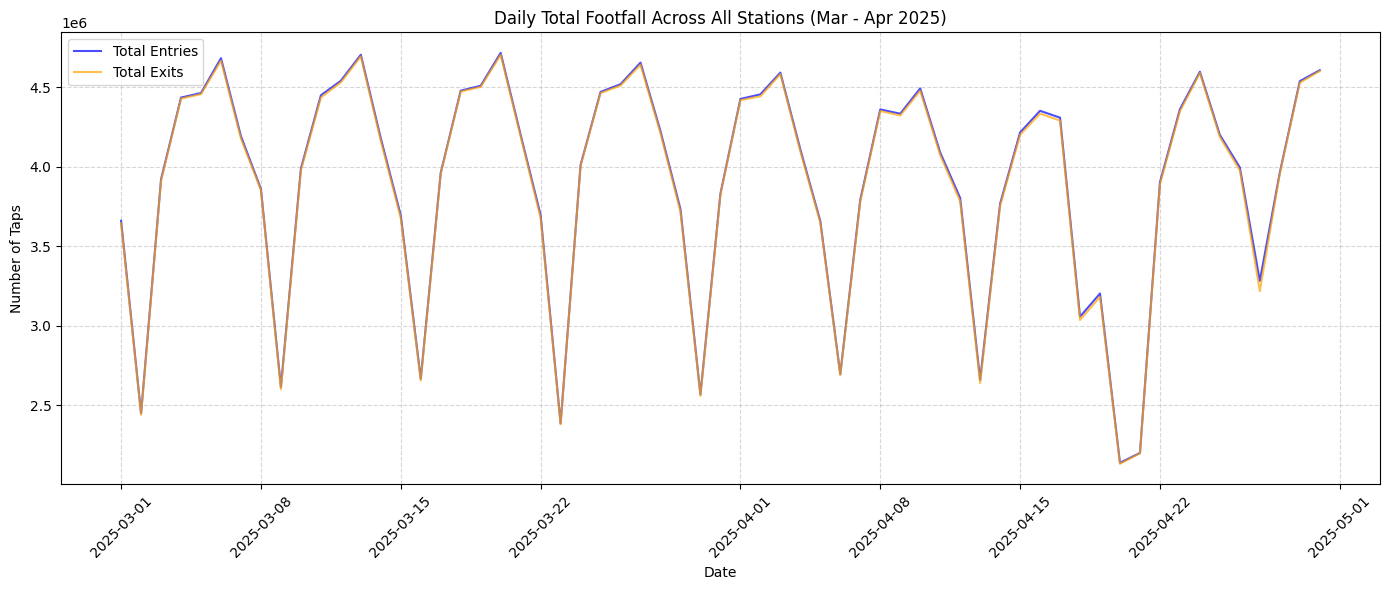

In [1446]:
import matplotlib.pyplot as plt
import seaborn as sns

# De-fragment the DataFrame to avoid PerformanceWarning
footfall_aggregate = footfall_aggregate.copy()

# 1. Calculate Total Entries and Exits for the map
# Identify entry and exit columns - Ensure we only pick date columns (start with digit)
entry_cols = [c for c in footfall_aggregate.columns if '_Entry' in c and c[0].isdigit()]
exit_cols = [c for c in footfall_aggregate.columns if '_Exit' in c and c[0].isdigit()]

# Sum across the row to get totals per station
footfall_aggregate['Total_Entry'] = footfall_aggregate[entry_cols].sum(axis=1)
footfall_aggregate['Total_Exit'] = footfall_aggregate[exit_cols].sum(axis=1)

# 2. Interactive Map of Total Entries
print("Interactive Map of Total Entries (Mar-Apr 2025):")
m = footfall_aggregate.explore(
    column='Total_Entry',
    tooltip=['Station', 'NETWORK', 'Total_Entry', 'Total_Exit'],
    cmap='rainbow',
    tiles='CartoDB positron',
    legend=True,
    legend_kwds={'caption': 'Total Entries'},
    style_kwds={'radius': 5} # Adjust marker size
)
display(m)

# Export
output_path = '/content/drive/MyDrive/2026 Spring/Capstone/CAPSTONE WORK PROGRESS/Data/TfL Station Footfall/interactive_map.HTML'
m.save(output_path)
print(f"Exported interactive map to {output_path}")

# 3. Time Series Plot of Aggregate Footfall
# Sum down the columns to get daily totals for the whole network
daily_entries = footfall_aggregate[entry_cols].sum()
daily_exits = footfall_aggregate[exit_cols].sum()

# Extract dates from column names for plotting
# Column format is 'YYYYMMDD_Entry'
dates = [col.split('_')[0] for col in entry_cols]
dates_dt = pd.to_datetime(dates, format='%Y%m%d')

plt.figure(figsize=(14, 6))
plt.plot(dates_dt, daily_entries.values, label='Total Entries', color='blue', alpha=0.7)
plt.plot(dates_dt, daily_exits.values, label='Total Exits', color='orange', alpha=0.7)

plt.title('Daily Total Footfall Across All Stations (Mar - Apr 2025)')
plt.xlabel('Date')
plt.ylabel('Number of Taps')
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

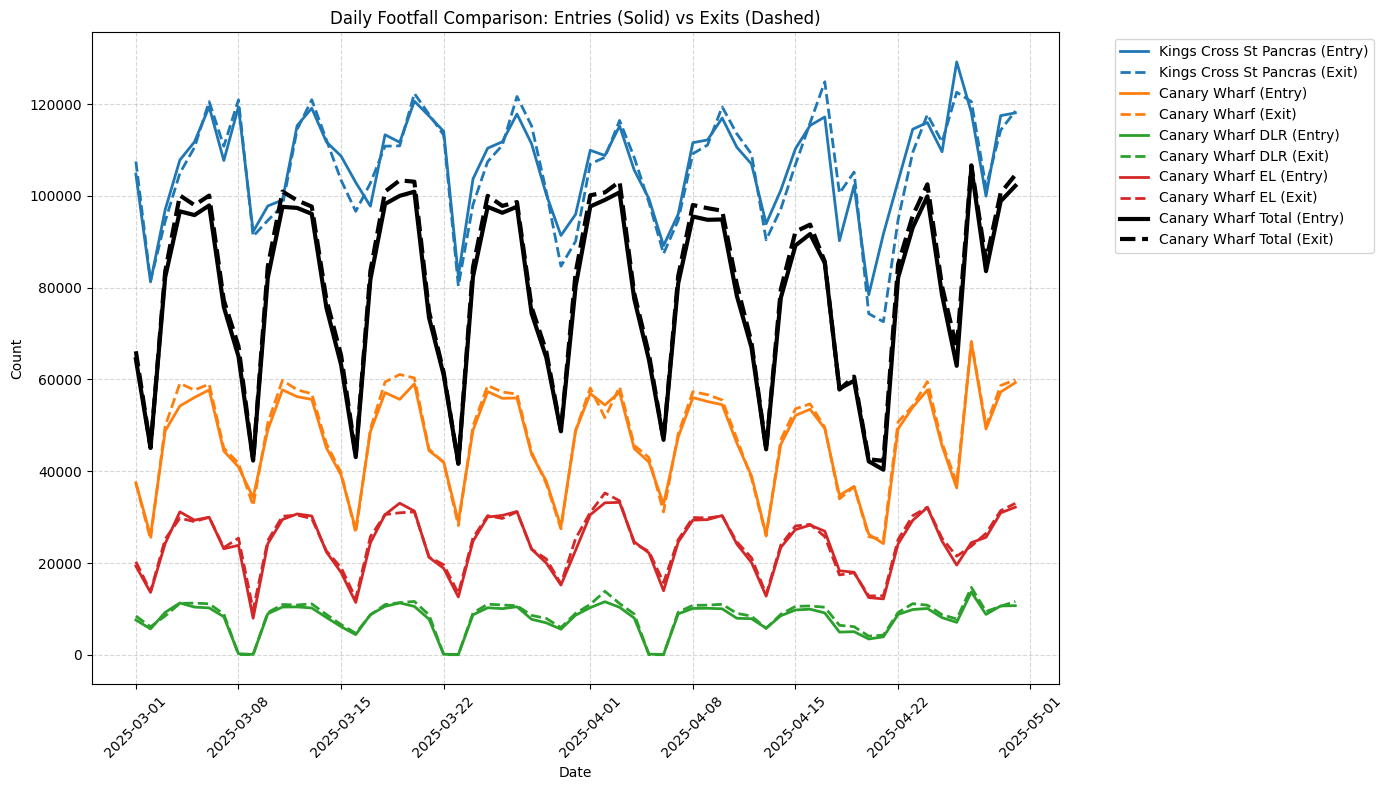

In [1447]:
# Define the stations to plot
target_stations = ['Kings Cross St Pancras', 'Canary Wharf', 'Canary Wharf DLR', 'Canary Wharf EL']

# Prepare dates from column names
# Re-using entry_cols and exit_cols from previous cell logic to ensure consistency
entry_cols = [c for c in footfall_aggregate.columns if '_Entry' in c and c[0].isdigit()]
exit_cols = [c for c in footfall_aggregate.columns if '_Exit' in c and c[0].isdigit()]
dates = [col.split('_')[0] for col in entry_cols]
dates_dt = pd.to_datetime(dates, format='%Y%m%d')

# Create a single plot
plt.figure(figsize=(14, 8))

# Define colors using a colormap
colors = plt.cm.tab10(range(len(target_stations)))

# Plot individual stations
for i, station in enumerate(target_stations):
    # Get row for this station
    row = footfall_aggregate[footfall_aggregate['Station'] == station]

    if not row.empty:
        # Extract series
        entries = row[entry_cols].values.flatten()
        exits = row[exit_cols].values.flatten()

        # Plot Entries (Solid)
        plt.plot(dates_dt, entries, label=f'{station} (Entry)', color=colors[i], linestyle='-', linewidth=2)

        # Plot Exits (Dashed)
        plt.plot(dates_dt, exits, label=f'{station} (Exit)', color=colors[i], linestyle='--', linewidth=2)

# Calculate and Plot Aggregated Canary Wharf
cw_stations = ['Canary Wharf', 'Canary Wharf DLR', 'Canary Wharf EL']
cw_data = footfall_aggregate[footfall_aggregate['Station'].isin(cw_stations)]

if not cw_data.empty:
    agg_entries = cw_data[entry_cols].sum().values
    agg_exits = cw_data[exit_cols].sum().values

    # Plot Aggregated (Black color to distinguish)
    plt.plot(dates_dt, agg_entries, label='Canary Wharf Total (Entry)', color='black', linestyle='-', linewidth=3)
    plt.plot(dates_dt, agg_exits, label='Canary Wharf Total (Exit)', color='black', linestyle='--', linewidth=3)

plt.title('Daily Footfall Comparison: Entries (Solid) vs Exits (Dashed)')
plt.xlabel('Date')
plt.ylabel('Count')
# Move legend outside to prevent obscuring data
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()